# Projet de EDA


In [36]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour afficher les graphiques directement dans le notebook
# %matplotlib inline

print("Environnement prêt pour l'EDA ! 🚀")

Environnement prêt pour l'EDA ! 🚀


### Exploring the data structure, including variables and data types.

In [37]:
# 1. Chargement des données
df = pd.read_csv('retail_store_inventory.csv')
# 2. Affichage des 5 premières lignes
print("--- Aperçu des données ---")
display(df.head())
# 3. Informations générales sur les colonnes et les types de données
print("\n--- Structure du Dataset ---")
df.info()
# 4. Statistiques descriptives de base
print("\n--- Statistiques ---")
display(df.describe())

--- Aperçu des données ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer



--- Structure du Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
me

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [38]:
import pandas as pd
import numpy as np

# 1. Charger le dataset original
df = pd.read_csv('retail_store_inventory.csv')

# On prend un échantillon de 5000 lignes pour travailler plus facilement
df_messy = df.sample(n=5000, random_state=42).copy() #.sample(n=5000) sélectionne 5000 lignes aléatoires, random_state=42 garantit un tirage reproductible, et .copy() crée une copie indépendante pour ne pas modifier df.

# 2. Injecter des valeurs manquantes (NaN)
# On efface 5% des Prix et 5% des Unités (frac=0.0) vendues
df_messy.loc[df_messy.sample(frac=0.05, random_state=1).index, 'Price'] = np.nan
df_messy.loc[df_messy.sample(frac=0.05, random_state=2).index, 'Units Sold'] = np.nan #.loc permet de sélectionner des données par index (lignes) et colonnes.

# 3. Injecter des valeurs aberrantes (Outliers)
# Des stocks négatifs et des prix absurdes (impossible dans la vraie vie)
df_messy.loc[df_messy.sample(frac=0.02, random_state=3).index, 'Inventory Level'] = -150
df_messy.loc[df_messy.sample(frac=0.01, random_state=4).index, 'Price'] = -99.99

# 4. Injecter des erreurs de texte (Casse et espaces parasites)
# Python va croire que 'Electronics' et ' electronics ' sont deux catégories différentes
df_messy['Category'] = df_messy['Category'].replace({
    'Electronics': ' electronics ',
    'Toys': 'TOYS',
    'Groceries': 'Groceries '
})

# 5. Injecter des formats de date incohérents
# On change le format de 10% des dates (de AAAA-MM-JJ à JJ/MM/AAAA)
idx_dates = df_messy.sample(frac=0.1, random_state=5).index
df_messy.loc[idx_dates, 'Date'] = pd.to_datetime(df_messy.loc[idx_dates, 'Date']).dt.strftime('%d/%m/%Y') #.dt.strftime('%d/%m/%Y') : Reformate les dates en chaîne de caractères

# 6. Ajouter des lignes dupliquées (Des erreurs de double saisie)
doublons = df_messy.sample(n=50, random_state=6)
df_messy = pd.concat([df_messy, doublons], ignore_index=True) #ignore_index=True : Réinitialise les index après concaténation

# 7. Sauvegarder notre nouveau terrain de jeu
df_messy.to_csv('retail_store_inventory_messy.csv', index=False)

print("Fichier 'retail_store_inventory_messy.csv' généré avec succès ! 🧹")

Fichier 'retail_store_inventory_messy.csv' généré avec succès ! 🧹


In [39]:
# 1. Chargement des données
df_messy = pd.read_csv('retail_store_inventory_messy.csv')
# 2. Affichage des 5 premières lignes
print("--- Aperçu des données ---")
display(df_messy.head())

--- Aperçu des données ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,24/10/2023,S002,P0008,electronics,North,225,138.0,144,139.31,40.47,0,Snowy,1,41.97,Winter
1,2023-03-11,S005,P0006,TOYS,North,200,105.0,119,117.55,18.65,15,Cloudy,1,16.65,Spring
2,2022-12-10,S001,P0005,Clothing,East,145,70.0,137,78.51,20.33,15,Snowy,0,18.04,Winter
3,2022-12-10,S001,P0018,electronics,West,350,105.0,157,103.11,98.65,15,Sunny,0,95.43,Spring
4,2023-01-22,S002,P0012,Groceries,North,145,76.0,145,92.47,10.04,20,Sunny,0,13.01,Winter


In [40]:
# 3. Informations générales sur les colonnes et les types de données
print("\n--- Structure du Dataset ---")
df_messy.info()


--- Structure du Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5050 non-null   str    
 1   Store ID            5050 non-null   str    
 2   Product ID          5050 non-null   str    
 3   Category            5050 non-null   str    
 4   Region              5050 non-null   str    
 5   Inventory Level     5050 non-null   int64  
 6   Units Sold          4798 non-null   float64
 7   Units Ordered       5050 non-null   int64  
 8   Demand Forecast     5050 non-null   float64
 9   Price               4802 non-null   float64
 10  Discount            5050 non-null   int64  
 11  Weather Condition   5050 non-null   str    
 12  Holiday/Promotion   5050 non-null   int64  
 13  Competitor Pricing  5050 non-null   float64
 14  Seasonality         5050 non-null   str    
dtypes: float64(4), int64(4), str(7)
memo

In [41]:
# ÉTAPE 1 : Suppression des doublons :

# 1. Compter le nombre exact de lignes en double
nombre_doublons = df_messy.duplicated().sum()
print(f"Nouvelle taille du dataset : {df_messy.shape[0]} lignes.")
print(f"Nombre de lignes en double avant nettoyage : {nombre_doublons}")

# 2. Afficher quelques exemples de ces doublons pour voir à quoi ils ressemblent
if nombre_doublons > 0:
    print("\n--- Voici quelques exemples de ces lignes dupliquées ---")
    # keep=False permet d'afficher l'original ET sa copie
    display(df_messy[df_messy.duplicated(keep=False)].sort_values(by=['Date', 'Store ID', 'Product ID']).head(6))

# 3. Supprimer les doublons de manière définitive
# inplace=True applique le changement directement sur notre DataFrame df_messy
df_messy.drop_duplicates(inplace=True) #N.B : inplace = True : retourne None

# 4. Taille finale
print(f"Nombre de lignes en double APRÈS nettoyage : {df_messy.duplicated().sum()}")
print(f"Nouvelle taille du dataset : {df_messy.shape[0]} lignes.") #df_messy.shape retourne un tuple : (nombre_de_lignes, nombre_de_colonnes)


Nouvelle taille du dataset : 5050 lignes.
Nombre de lignes en double avant nettoyage : 50

--- Voici quelques exemples de ces lignes dupliquées ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
2717,04/03/2022,S005,P0005,Furniture,East,109,66.0,80,56.70,NaN,20,Cloudy,1,93.02,Autumn
5042,04/03/2022,S005,P0005,Furniture,East,109,66.0,80,56.70,NaN,20,Cloudy,1,93.02,Autumn
279,05/06/2022,S003,P0011,Furniture,West,443,170.0,87,176.99,52.54,10,Cloudy,0,55.08,Winter
5015,05/06/2022,S003,P0011,Furniture,West,443,170.0,87,176.99,52.54,10,Cloudy,0,55.08,Winter
4382,13/10/2023,S001,P0013,Groceries,East,98,17.0,124,24.67,34.31,0,Snowy,1,30.69,Winter
5043,13/10/2023,S001,P0013,Groceries,East,98,17.0,124,24.67,34.31,0,Snowy,1,30.69,Winter


Nombre de lignes en double APRÈS nettoyage : 0
Nouvelle taille du dataset : 5000 lignes.


In [42]:
# ÉTAPE 2 : Nettoyage des textes et des dates ---

print("--- 1. NETTOYAGE DES CATÉGORIES ---")
# On affiche les catégories uniques avant le nettoyage pour voir les erreurs
print("Catégories AVANT :", df_messy['Category'].unique()) #unique : .unique() → retourne les valeurs sans doublons

# .str.strip() enlève les espaces invisibles au début et à la fin du texte
# .str.title() met une majuscule au début de chaque mot pour tout uniformiser
df_messy['Category'] = df_messy['Category'].str.strip().str.title()

print("Catégories APRÈS :", df_messy['Category'].unique())


print("\n--- 2. STANDARDISATION DES DATES ---")
# On vérifie comment Python considère la colonne 'Date' actuellement (probablement comme du texte 'object')
print("Type de la colonne Date AVANT :", df_messy['Date'].dtype)

# On force la conversion de toute la colonne en vrai format temporel universel (datetime)
# errors='coerce' permet de transformer les dates totalement incompréhensibles en valeurs manquantes (NaT) au lieu de faire planter le code
df_messy['Date'] = pd.to_datetime(df_messy['Date'], errors='coerce',dayfirst=True)

print("Type de la colonne Date APRÈS :", df_messy['Date'].dtype)

--- 1. NETTOYAGE DES CATÉGORIES ---
Catégories AVANT : <StringArray>
[' electronics ', 'TOYS', 'Clothing', 'Groceries ', 'Furniture']
Length: 5, dtype: str
Catégories APRÈS : <StringArray>
['Electronics', 'Toys', 'Clothing', 'Groceries', 'Furniture']
Length: 5, dtype: str

--- 2. STANDARDISATION DES DATES ---
Type de la colonne Date AVANT : str
Type de la colonne Date APRÈS : datetime64[us]


In [43]:
# --- ÉTAPE 3 : Gestion des valeurs manquantes ---

print("--- 1. DIAGNOSTIC AVANT NETTOYAGE ---")
# isnull().sum() compte le nombre de cases vides pour chaque colonne
print(df_messy.isnull().sum())
print("\n... Nettoyage en cours ...")
# 1. On calcule les médianes
prix_median = df_messy['Price'].median()
quantite_median = df_messy['Units Sold'].median()
# 2. On remplace (fillna) les trous par ces médianes
# On réassigne la colonne nettoyée à elle-même
df_messy['Price'] = df_messy['Price'].fillna(prix_median)
df_messy['Units Sold'] = df_messy['Units Sold'].fillna(quantite_median)
print("\n--- 2. VÉRIFICATION APRÈS NETTOYAGE ---")
# On recompte pour vérifier qu'il n'y a plus de trous
print(df_messy.isnull().sum())

--- 1. DIAGNOSTIC AVANT NETTOYAGE ---
Date                  4500
Store ID                 0
Product ID               0
Category                 0
Region                   0
Inventory Level          0
Units Sold             250
Units Ordered            0
Demand Forecast          0
Price                  245
Discount                 0
Weather Condition        0
Holiday/Promotion        0
Competitor Pricing       0
Seasonality              0
dtype: int64

... Nettoyage en cours ...

--- 2. VÉRIFICATION APRÈS NETTOYAGE ---
Date                  4500
Store ID                 0
Product ID               0
Category                 0
Region                   0
Inventory Level          0
Units Sold               0
Units Ordered            0
Demand Forecast          0
Price                    0
Discount                 0
Weather Condition        0
Holiday/Promotion        0
Competitor Pricing       0
Seasonality              0
dtype: int64


In [44]:
# ÉTAPE 4 : Gestion des valeurs aberrantes (Outliers)

print("--- 1. DIAGNOSTIC DES OUTLIERS ---")
# On cherche les lignes où le prix ou le stock est inférieur à 0
outliers_prix = df_messy[df_messy['Price'] < 0]
outliers_stock = df_messy[df_messy['Inventory Level'] < 0]
print(f"Nombre de prix négatifs trouvés : {len(outliers_prix)}")
print(f"Nombre de stocks négatifs trouvés : {len(outliers_stock)}")
print("\n... Nettoyage en cours ...")
# 2. Correction : On va utiliser la fonction .abs() (valeur absolue) pour transformer les valeurs négatives en positives
# (On part du principe que c'était une simple erreur de frappe avec un signe '-')
df_messy['Price'] = df_messy['Price'].abs()
df_messy['Inventory Level'] = df_messy['Inventory Level'].abs()
print("\n--- 2. VÉRIFICATION APRÈS NETTOYAGE ---")
# On vérifie que le minimum n'est plus en dessous de zéro
print(f"Prix minimum dans le dataset : {df_messy['Price'].min()}")
print(f"Stock minimum dans le dataset : {df_messy['Inventory Level'].min()}")
print("\nOpération terminée ! Ton dataset est 100% propre. ✨")

--- 1. DIAGNOSTIC DES OUTLIERS ---
Nombre de prix négatifs trouvés : 50
Nombre de stocks négatifs trouvés : 100

... Nettoyage en cours ...

--- 2. VÉRIFICATION APRÈS NETTOYAGE ---
Prix minimum dans le dataset : 10.01
Stock minimum dans le dataset : 50

Opération terminée ! Ton dataset est 100% propre. ✨


### Quelles catégories de produits génèrent le plus de volume ?

### Est-ce que les promotions augmentent vraiment le nombre d'unités vendues par commande ?

--- DÉBUT DE L'ANALYSE VISUELLE ---


C:\Users\user\AppData\Local\Temp\ipykernel_26940\1569249817.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventes_par_categorie, x='Category', y='Units Sold', palette='viridis') #sns.barplot(...) : On demande à Seaborn de faire un diagramme en barres.


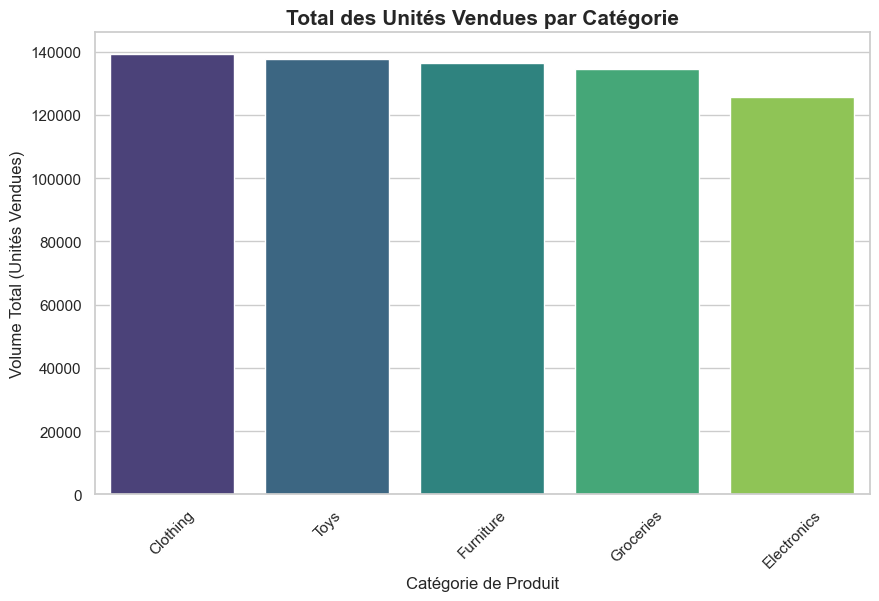

C:\Users\user\AppData\Local\Temp\ipykernel_26940\1569249817.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_messy, x='Holiday/Promotion', y='Units Sold', palette='Set2')


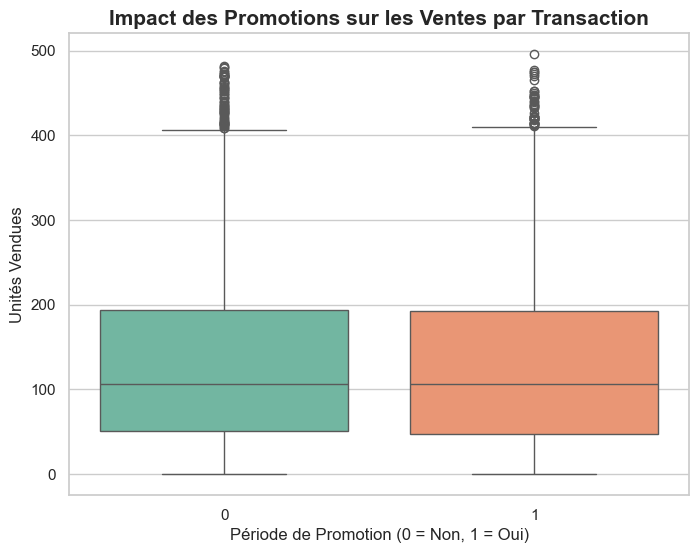

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
# Configuration du style visuel des graphiques pour faire pro
sns.set_theme(style="whitegrid") #style="whitegrid" : C'est le nom du thème précis que vous choisissez. "White" signifie fond blanc, et "grid" signifie grille.
print("--- DÉBUT DE L'ANALYSE VISUELLE ---")
# ---------------------------------------------------------
# Graphique 1 : Volume de ventes par catégorie
# ---------------------------------------------------------
plt.figure(figsize=(10, 6)) #size du graphe
# On groupe les données par catégorie et on additionne les unités vendues
ventes_par_categorie = df_messy.groupby('Category')['Units Sold'].sum().reset_index() #.reset_index() → transforme cet index en colonne normale
ventes_par_categorie = ventes_par_categorie.sort_values(by='Units Sold', ascending=False)
# Création d'un diagramme en barres
sns.barplot(data=ventes_par_categorie, x='Category', y='Units Sold', palette='viridis') #sns.barplot(...) : On demande à Seaborn de faire un diagramme en barres.
plt.title('Total des Unités Vendues par Catégorie', fontsize=15, fontweight='bold')
plt.xlabel('Catégorie de Produit', fontsize=12)
plt.ylabel('Volume Total (Unités Vendues)', fontsize=12)
plt.xticks(rotation=45) # Incline le texte pour que ce soit lisible (plt.xticks(...) : Gère le texte en bas)
plt.show()
# ---------------------------------------------------------
# Graphique 2 : Impact des promotions sur les ventes
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Création d'une boîte à moustaches (Boxplot) pour voir la répartition
# 0 = Pas de promotion, 1 = En promotion
sns.boxplot(data=df_messy, x='Holiday/Promotion', y='Units Sold', palette='Set2')
plt.title('Impact des Promotions sur les Ventes par Transaction', fontsize=15, fontweight='bold')
plt.xlabel('Période de Promotion (0 = Non, 1 = Oui)', fontsize=12)
plt.ylabel('Unités Vendues', fontsize=12)
plt.show()

--- GÉNÉRATION DES GRAPHIQUES AVANCÉS ---


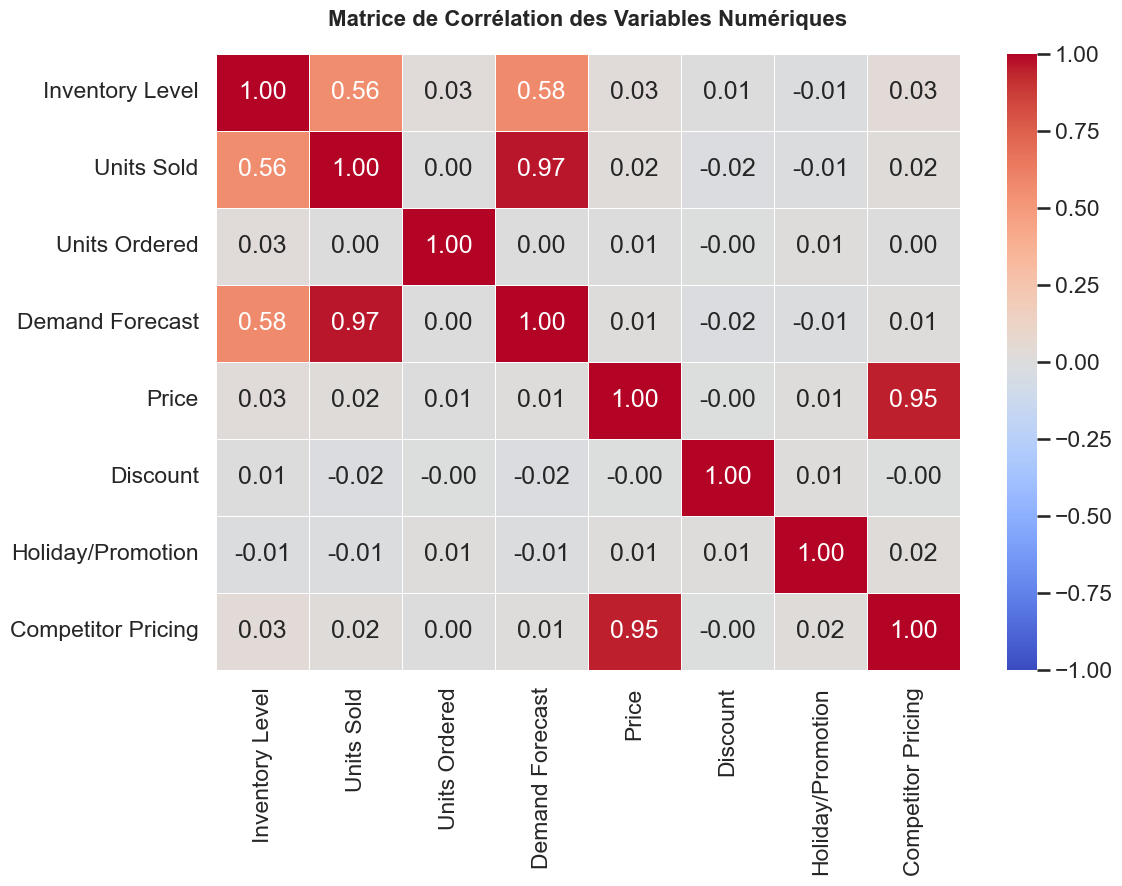

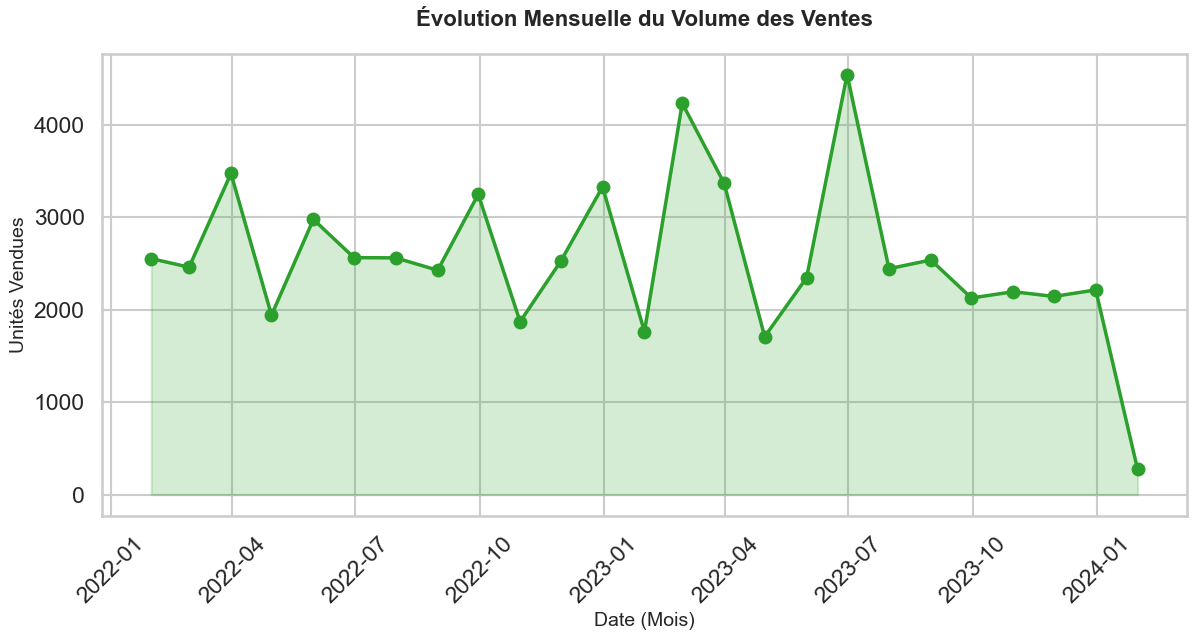

C:\Users\user\AppData\Local\Temp\ipykernel_26940\2071928633.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_messy, x='Weather Condition', y='Units Sold', palette='magma') # C’est une fonction de Seaborn pour créer un violin plot (qui montre la densite)


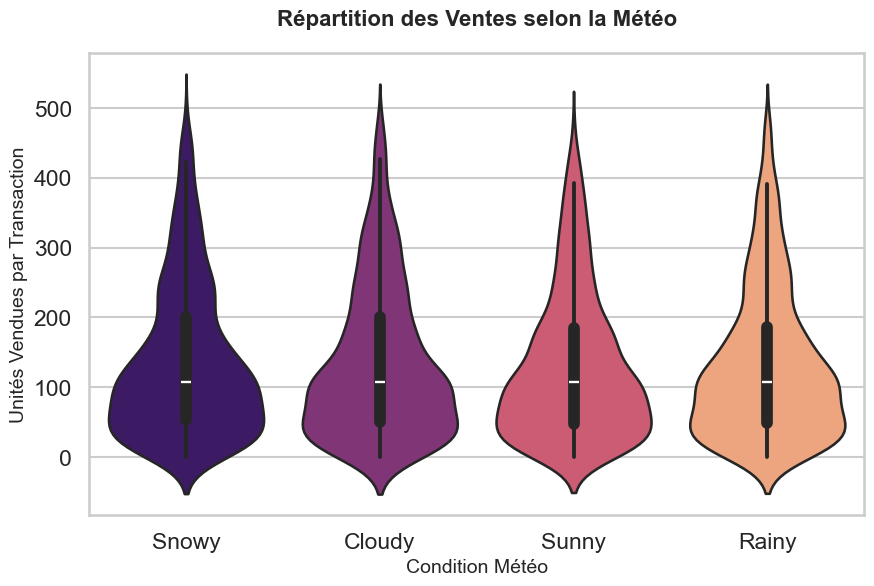

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Configuration du style premium
sns.set_theme(style="whitegrid", context="talk")
print("--- GÉNÉRATION DES GRAPHIQUES AVANCÉS ---")
# ---------------------------------------------------------
# Graphique 3 : Matrice de Corrélation (Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
# On sélectionne uniquement les colonnes numériques pour la corrélation
colonnes_num = df_messy.select_dtypes(include=[np.number]) # Garder que les colonnes qui ont des chiffres
correlation_matrix = colonnes_num.corr()
# Création de la Heatmap avec des annotations (chiffres dans les cases)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1) #annot=True : (Annotation) Cela force l'affichage du chiffre exact à l'intérieur de chaque petit carré de couleur.
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=16, fontweight='bold', pad=20)
plt.show()
# ---------------------------------------------------------
# Graphique 4 : Évolution Temporelle des Ventes
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
# On s'assure que la date est bien l'index, puis on groupe par mois ('ME') pour lisser la courbe
df_time = df_messy.set_index('Date') # Date devient l’index. Elle n’est plus une colonne c
ventes_mensuelles = df_time['Units Sold'].resample('ME').sum() #les regrouper par mois (M : mounth , E : end)
# Tracé de la courbe avec une zone ombrée en dessous pour le style
plt.plot(ventes_mensuelles.index, ventes_mensuelles.values, color='#2ca02c', marker='o', linewidth=2.5)
plt.fill_between(ventes_mensuelles.index, ventes_mensuelles.values, color='#2ca02c', alpha=0.2)
plt.title('Évolution Mensuelle du Volume des Ventes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date (Mois)', fontsize=14)
plt.ylabel('Unités Vendues', fontsize=14)
plt.xticks(rotation=45)
plt.show()
# ---------------------------------------------------------
# Graphique 5 : L'impact de la météo (Violin Plot)
# ---------------------------------------------------------
# Le Violin Plot est plus stylé et informatif qu'un simple Boxplot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_messy, x='Weather Condition', y='Units Sold', palette='magma') # C’est une fonction de Seaborn pour créer un violin plot (qui montre la densite)
plt.title('Répartition des Ventes selon la Météo', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Condition Météo', fontsize=14)
plt.ylabel('Unités Vendues par Transaction', fontsize=14)
plt.show()

## Feature Engineering

C:\Users\user\AppData\Local\Temp\ipykernel_26940\2036881208.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_messy, x='Positionnement', y='Units Sold', palette='coolwarm')


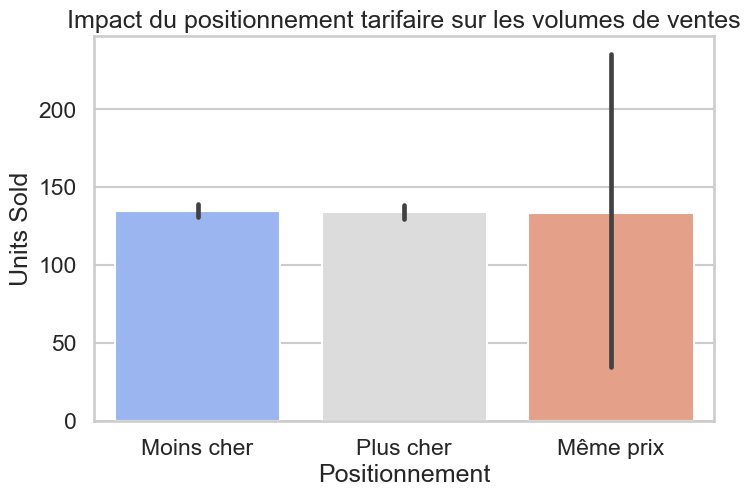

In [47]:
# Feature 1 : L'Analyse de la Compétitivité (Price Gap) --> Comparer ton prix avec celui des concurrents
# Création d'un indicateur de compétitivité
df_messy['Difference_Prix'] = df_messy['Price'] - df_messy['Competitor Pricing']
# Création d'une catégorie pour simplifier la lecture
def statut_prix(diff):
    if diff > 0: return 'Plus cher'
    elif diff < 0: return 'Moins cher'
    else: return 'Même prix'
df_messy['Positionnement'] = df_messy['Difference_Prix'].apply(statut_prix) #.apply() = appliquer une fonction à chaque ligne
# Un graphique pour voir si être "Moins cher" fait vraiment vendre plus
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sns.barplot(data=df_messy, x='Positionnement', y='Units Sold', palette='coolwarm')
plt.title("Impact du positionnement tarifaire sur les volumes de ventes")
plt.show()

In [48]:
# Feature 2 : L'Indicateur de Rupture de Stock (Stock Risk)
# Calcul du stock restant après les ventes
df_messy['Stock_Restant'] = df_messy['Inventory Level'] - df_messy['Units Sold']
# Identifier les produits critiques (ex: moins de 20 articles restants)
produits_en_danger = df_messy[df_messy['Stock_Restant'] < 20]
print(f"⚠️ Alerte : Il y a {len(produits_en_danger)} transactions où le stock final est dangereusement bas (< 20 unités).")

⚠️ Alerte : Il y a 533 transactions où le stock final est dangereusement bas (< 20 unités).


In [49]:
# Feature 3 : L'Effet "Wahou" avec des Graphiques Interactifs (Plotly) :interactif. zoom et déplacement dans le graphique. survol pour voir les valeurs exactes. filtres, sliders, menus déroulants
import plotly.express as px
# On regroupe les données
ventes_cat = df_messy.groupby('Category', as_index=False)['Units Sold'].sum() #as_index=False → garde Category comme colonne normale
# Création d'un graphique interactif
fig = px.bar(ventes_cat, x='Category', y='Units Sold',
             title='Volume Total des Ventes par Catégorie (Interactif)',
             color='Units Sold', color_continuous_scale='Viridis')
# Affichage (passe ta souris sur les barres dans ton notebook !)
fig.show()

### Business Intelligence

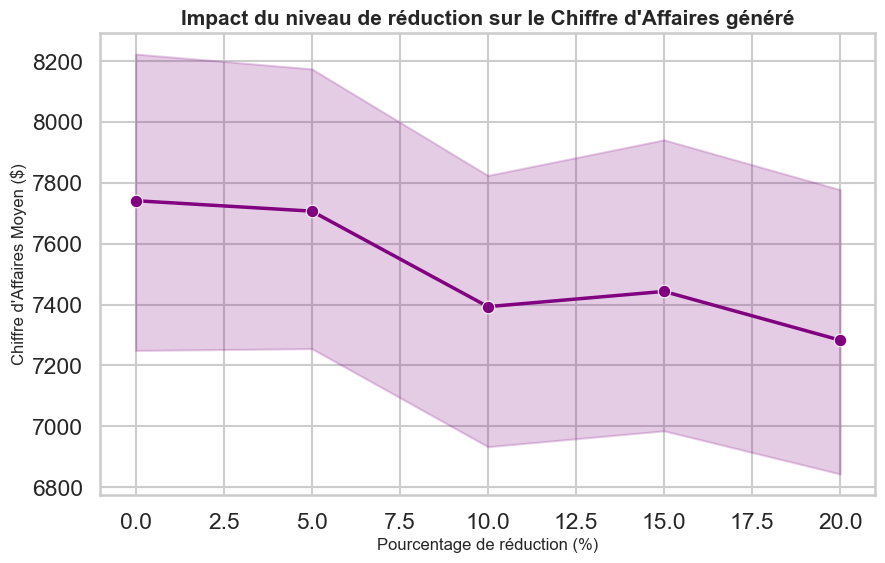

In [50]:
# 1. Création de la métrique reine : Le Chiffre d'Affaires (Revenue)
# Création de la colonne Chiffre d'Affaires
df_messy['Revenue'] = df_messy['Price'] * df_messy['Units Sold']
# Analyse : Quel est l'impact du pourcentage de réduction sur le chiffre d'affaires moyen ?
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_messy, x='Discount', y='Revenue', marker='o', color='purple', linewidth=2.5) #montre la tendance du chiffre d’affaires selon la réduction
plt.title("Impact du niveau de réduction sur le Chiffre d'Affaires généré", fontsize=15, fontweight='bold')
plt.xlabel("Pourcentage de réduction (%)", fontsize=12)
plt.ylabel("Chiffre d'Affaires Moyen ($)", fontsize=12)
plt.show()

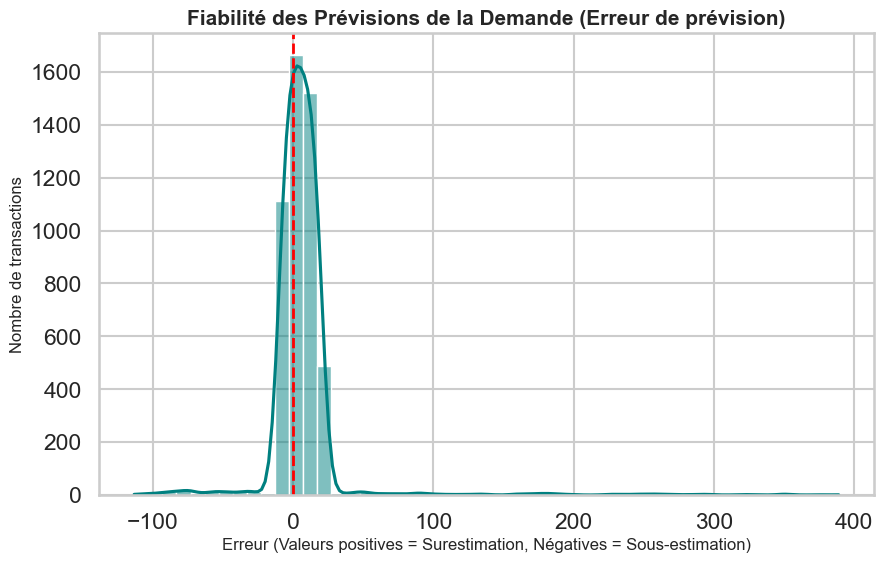

In [51]:
# 2. Évaluer la fiabilité des prévisions (Forecast Accuracy) : Demand Forecast → ce que l’algorithme du magasin prévoit comme ventes et Units Sold → ce qui a été réellement vendu
# Calcul de l'erreur de prévision (Prévision - Réalité)
df_messy['Forecast_Error'] = df_messy['Demand Forecast'] - df_messy['Units Sold']
# Création d'un graphique pour voir si le magasin surestime ou sous-estime souvent ses ventes
plt.figure(figsize=(10, 6))
sns.histplot(df_messy['Forecast_Error'], bins=50, kde=True, color='teal') #Histogramme → montre combien de fois une erreur apparaît (bins=50 → divise les erreurs en 50 intervalles pour mieux voir la répartition , kde=True → ajoute une courbe de densité, pour voir la tendance globale)
plt.title("Fiabilité des Prévisions de la Demande (Erreur de prévision)", fontsize=15, fontweight='bold')
plt.xlabel("Erreur (Valeurs positives = Surestimation, Négatives = Sous-estimation)", fontsize=12)
plt.ylabel("Nombre de transactions", fontsize=12)
# Ajout d'une ligne rouge à zéro (prévision parfaite)
plt.axvline(0, color='red', linestyle='--', linewidth=2) #Ligne rouge = prévision parfaite
plt.show()

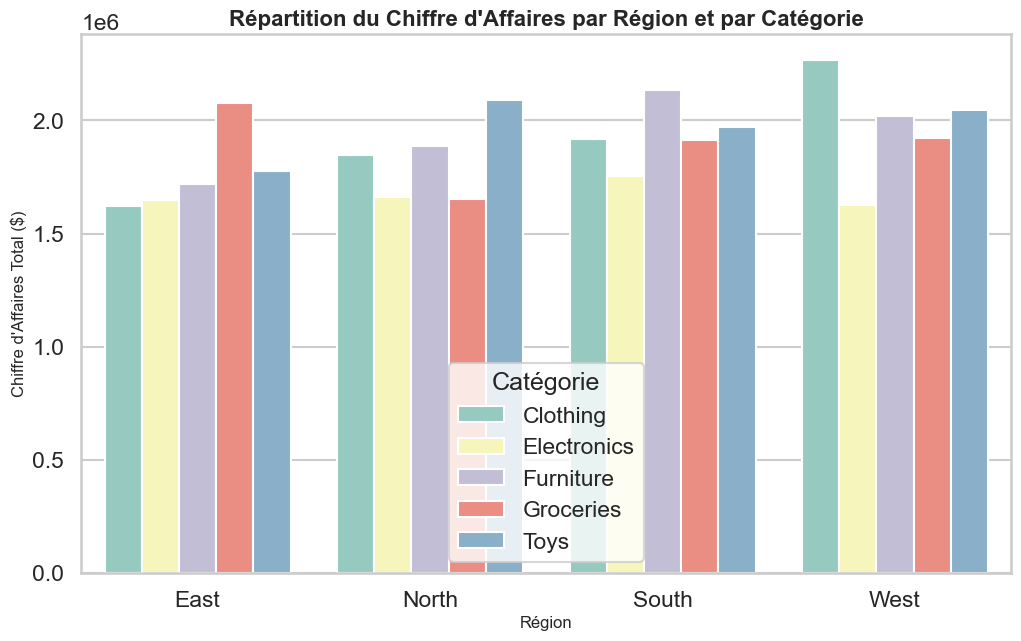

In [52]:
# 3. La performance régionale (Où sont les meilleurs clients ?)
# Regroupement du chiffre d'affaires par région et par catégorie
revenue_region = df_messy.groupby(['Region', 'Category'])['Revenue'].sum().reset_index()
# Création d'un graphique en barres empilées (très visuel et pro)
plt.figure(figsize=(12, 7))
sns.barplot(data=revenue_region, x='Region', y='Revenue', hue='Category', palette='Set3')
plt.title("Répartition du Chiffre d'Affaires par Région et par Catégorie", fontsize=16, fontweight='bold')
plt.xlabel("Région", fontsize=12)
plt.ylabel("Chiffre d'Affaires Total ($)", fontsize=12)
plt.legend(title='Catégorie')
plt.show()

In [18]:
print(df_messy[df_messy['Stock_Restant'] == 0])

           Date Store ID Product ID     Category Region  Inventory Level  \
810         NaT     S004      P0005    Groceries   East              178   
1050        NaT     S003      P0004  Electronics   West               66   
1068        NaT     S002      P0001     Clothing   East               68   
1477        NaT     S003      P0015     Clothing   East              261   
1538 2023-03-13     S004      P0009    Furniture   West              164   
1580        NaT     S001      P0010  Electronics  North               74   
1601 2023-04-06     S001      P0005         Toys  South              164   
1787        NaT     S003      P0004     Clothing  North              196   
2015        NaT     S001      P0009    Furniture   West              186   
2394        NaT     S001      P0004     Clothing   East              354   
2456 2023-04-01     S003      P0010    Furniture   West               77   
2600        NaT     S004      P0009     Clothing   West              281   
2702        